# WR RNN - Attention Pooling + Player Embeddings

Dodajemo dve kljucne ideje na RNN v2:

1. Attention pooling - umesto da uzmemo samo poslednje hidden state, self-attention nauci ponderisano prosecavanje svih timestep-ova. LSTM/GRU cesto zaboravlja ranije utakmice.
2. Player embeddings - Embedding(n_players, 8) koji uci per-player talent vektor. Hvata nemerljive osobine (skill, durability) koje statistika ne vidi.

Treniramo 4 modela radi direktnog poredjenja:
- `LSTM + sqrt target`
- `LSTM + log1p target`
- `GRU + sqrt target`
- `GRU + log1p target`

Bez Optuna search-a - koristimo jednu razumnu konfiguraciju, radi cistog head-to-head poredjenja.


---
## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import os, json, time, random

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, losses, Model, Input, regularizers
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Bidirectional,
    LayerNormalization, GaussianNoise,
    Masking, Concatenate, Embedding, Flatten
)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = (14, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

print(f'TensorFlow {tf.__version__}')


TensorFlow 2.21.0


---
## 2. Data Loading & Feature Engineering

In [2]:
df = pd.read_csv('../../data/fully combined/wr_all_weeks.csv')
df['week'] = df['game_id'].str.split('_').str[1].astype(int)
df = df.sort_values(['receiver_player_id', 'season', 'week']).reset_index(drop=True)

# Team change
df['player_team_inferred'] = np.where(
    (df['home_team'] == df['defteam']) & (df['away_team'] != df['defteam']),
    df['away_team'],
    np.where(
        (df['away_team'] == df['defteam']) & (df['home_team'] != df['defteam']),
        df['home_team'], np.nan
    )
)
prev_team = df.groupby('receiver_player_id')['player_team_inferred'].shift(1)
df['team_changed'] = (
    df['player_team_inferred'].notna() & prev_team.notna()
    & (df['player_team_inferred'] != prev_team)
).astype(int)

prev_season = df.groupby('receiver_player_id')['season'].shift(1)
df['is_new_season'] = (prev_season.notna() & (df['season'] != prev_season)).astype(int)

df['season_week_abs'] = (df['season'] - 2015) * 22 + df['week']
df['weeks_since_last_game'] = (
    df.groupby('receiver_player_id')['season_week_abs']
    .diff().fillna(1).clip(lower=1).astype(float)
)
df.drop(columns=['season_week_abs'], inplace=True)

# Previous-season career averages
season_career = (
    df.groupby(['receiver_player_id', 'season'], as_index=False)
    .agg(avg_yards=('receiving_yards', 'mean'),
         avg_target_share=('target_share', 'mean'),
         avg_epa=('epa', 'mean'),
         avg_air_yard_share=('air_yard_share', 'mean'),
         avg_catch_rate=('catch_rate', 'mean'),
         games_played=('game_id', 'count'))
    .sort_values(['receiver_player_id', 'season'])
)
for c in ['avg_yards', 'avg_target_share', 'avg_epa',
          'avg_air_yard_share', 'avg_catch_rate', 'games_played']:
    season_career[f'{c}_last_season'] = (
        season_career.groupby('receiver_player_id')[c].shift(1)
    )
career_cols = [f'{c}_last_season' for c in
               ['avg_yards', 'avg_target_share', 'avg_epa',
                'avg_air_yard_share', 'avg_catch_rate', 'games_played']]
season_career = season_career[['receiver_player_id', 'season'] + career_cols]
df = df.merge(season_career, on=['receiver_player_id', 'season'], how='left')
df[career_cols] = df[career_cols].fillna(0)

# Engineered temporal channels (lag1 + roll3 for key stats)
temporal_base = ['receiving_yards', 'targets', 'receptions', 'epa', 'target_share', 'air_yard_share']
df = df.sort_values(['receiver_player_id', 'season', 'week']).reset_index(drop=True)
g = df.groupby('receiver_player_id', group_keys=False)
for col in temporal_base:
    df[f'{col}_lag1'] = g[col].shift(1).fillna(0)
    df[f'{col}_roll3'] = g[col].shift(1).rolling(3, min_periods=1).mean().reset_index(level=0, drop=True).fillna(0)

lag_cols = [f'{c}_lag1' for c in temporal_base]
roll_cols = [f'{c}_roll3' for c in temporal_base]
print(f'After engineering: {df.shape}')


After engineering: (46115, 122)


---
## 3. Feature Groups

In [3]:
seq_raw_cols = [
    'receiving_yards', 'targets', 'receptions', 'air_yards', 'yac',
    'first_downs', 'tds', 'epa', 'wpa',
    'catch_rate', 'yards_per_target', 'avg_depth', 'adot', 'success_rate',
    'target_share', 'air_yard_share', 'target_share_std', 'reception_std',
    'team_pass_attempts', 'team_air_yards', 'team_epa',
    'qb_completions', 'qb_attempts', 'qb_comp_pct', 'qb_cpoe',
    'avg_score_diff', 'wp_var',
    'yards_Q1', 'yards_Q2', 'yards_Q3',
    'def_yards_dev', 'def_epa_dev',
    'weeks_since_last_game',
]
seq_feature_cols = seq_raw_cols + lag_cols + roll_cols

static_feature_cols = [
    'pregame_spread', 'pregame_total',
    'surface', 'is_dome', 'temp_f', 'humidity_pct', 'wind_mph',
    'is_rain', 'is_snow', 'is_clear',
    'week', 'team_changed', 'is_new_season', 'weeks_since_last_game',
    'avg_yards_last_season', 'avg_target_share_last_season',
    'avg_epa_last_season', 'avg_air_yard_share_last_season',
    'avg_catch_rate_last_season', 'games_played_last_season',
]

n_seq_features = len(seq_feature_cols)
n_static_features = len(static_feature_cols)
print(f'Sequence channels: {n_seq_features}  Static: {n_static_features}')


Sequence channels: 45  Static: 20


---
## 4. Player ID Encoding for Embeddings

Fit na train igrace, OOV=0 za nepoznate (val/test rookies).


In [4]:
train_seasons = list(range(2015, 2022))
val_seasons = [2022, 2023]
test_seasons = [2024, 2025]

train_players = df.loc[df['season'].isin(train_seasons), 'receiver_player_id'].unique()
player_to_idx = {pid: i + 1 for i, pid in enumerate(sorted(train_players))}  # 0 reserved for OOV
n_players = len(player_to_idx) + 1  # +1 for OOV

df['player_idx'] = df['receiver_player_id'].map(player_to_idx).fillna(0).astype(int)

n_oov_val = int((df.loc[df['season'].isin(val_seasons), 'player_idx'] == 0).sum())
n_oov_test = int((df.loc[df['season'].isin(test_seasons), 'player_idx'] == 0).sum())
print(f'Total unique player indices: {n_players} (incl. OOV=0)')
print(f'OOV in val: {n_oov_val} ({100*n_oov_val/df["season"].isin(val_seasons).sum():.1f}%)')
print(f'OOV in test: {n_oov_test} ({100*n_oov_test/df["season"].isin(test_seasons).sum():.1f}%)')


Total unique player indices: 1308 (incl. OOV=0)
OOV in val: 2282 (24.9%)
OOV in test: 3185 (49.9%)


---
## 5. Scaling (target stays unscaled)

In [5]:
df[seq_feature_cols] = df[seq_feature_cols].fillna(0)
df[static_feature_cols] = df[static_feature_cols].fillna(0)

train_mask_df = df['season'].isin(train_seasons)

seq_scaler = StandardScaler()
seq_scaler.fit(df.loc[train_mask_df, seq_feature_cols])

static_scaler = StandardScaler()
static_scaler.fit(df.loc[train_mask_df, static_feature_cols])

df_scaled = df.copy()
df_scaled[seq_feature_cols] = seq_scaler.transform(df[seq_feature_cols])
df_scaled[static_feature_cols] = static_scaler.transform(df[static_feature_cols])
df_scaled['receiving_yards_orig'] = df['receiving_yards'].values
print('Scaled.')


Scaled.


---
## 6. Build Padded Sequences (with player indices)

In [6]:
SEQ_LEN = 6

def build_sequences(df_scaled, seq_feats, static_feats, seq_len):
    X_seq, X_static, X_pid, y, seasons = [], [], [], [], []
    for pid, group in df_scaled.groupby('receiver_player_id'):
        group = group.sort_values(['season', 'week'])
        n = len(group)
        if n < 2:
            continue
        seq_vals = group[seq_feats].values
        static_vals = group[static_feats].values
        yards = group['receiving_yards_orig'].values
        season_vals = group['season'].values
        pid_vals = group['player_idx'].values
        for t in range(1, n):
            start = max(0, t - seq_len)
            past = seq_vals[start:t]
            actual_len = past.shape[0]
            if actual_len < seq_len:
                padding = np.zeros((seq_len - actual_len, len(seq_feats)))
                past = np.vstack([padding, past])
            X_seq.append(past)
            X_static.append(static_vals[t])
            X_pid.append(pid_vals[t])
            y.append(yards[t])
            seasons.append(season_vals[t])
    return (
        np.array(X_seq, dtype=np.float32),
        np.array(X_static, dtype=np.float32),
        np.array(X_pid, dtype=np.int32),
        np.array(y, dtype=np.float32),
        np.array(seasons),
    )

t0 = time.time()
X_seq_all, X_static_all, X_pid_all, y_all, seasons_all = build_sequences(
    df_scaled, seq_feature_cols, static_feature_cols, SEQ_LEN)
print(f'Built {len(X_seq_all)} sequences in {time.time()-t0:.1f}s')
print(f'Shapes: seq={X_seq_all.shape}, static={X_static_all.shape}, pid={X_pid_all.shape}')
print(f'y: mean={y_all.mean():.2f}, std={y_all.std():.2f}')


Built 44396 sequences in 2.0s
Shapes: seq=(44396, 6, 45), static=(44396, 20), pid=(44396,)
y: mean=30.16, std=31.98


---
## 7. Temporal Splits

In [7]:
tr = np.isin(seasons_all, train_seasons)
va = np.isin(seasons_all, val_seasons)
te = np.isin(seasons_all, test_seasons)

X_seq_tr, X_static_tr, X_pid_tr, y_tr = X_seq_all[tr], X_static_all[tr], X_pid_all[tr], y_all[tr]
X_seq_va, X_static_va, X_pid_va, y_va = X_seq_all[va], X_static_all[va], X_pid_all[va], y_all[va]
X_seq_te, X_static_te, X_pid_te, y_te = X_seq_all[te], X_static_all[te], X_pid_all[te], y_all[te]

print(f'train={len(y_tr)}  val={len(y_va)}  test={len(y_te)}')


train=29276  val=8921  test=6199


---
## 8. Target Transformations

Dva transforma: `sqrt` i `log1p`. Svaki model trenira sa svojim transformom.


In [8]:
class TargetTransform:
    def __init__(self, name):
        self.name = name
    def forward(self, y):
        if self.name == 'sqrt':
            return np.sqrt(np.clip(y, 0, None))
        elif self.name == 'log1p':
            return np.log1p(np.clip(y, 0, None))
        raise ValueError(self.name)
    def inverse(self, y_pred):
        y_pred = np.clip(y_pred, 0, None)
        if self.name == 'sqrt':
            return y_pred ** 2
        elif self.name == 'log1p':
            return np.expm1(y_pred)
        raise ValueError(self.name)

sqrt_t = TargetTransform('sqrt')
log1p_t = TargetTransform('log1p')

# Pre-compute targets in each space
y_tr_sqrt = sqrt_t.forward(y_tr);  y_va_sqrt = sqrt_t.forward(y_va);  y_te_sqrt = sqrt_t.forward(y_te)
y_tr_log  = log1p_t.forward(y_tr); y_va_log  = log1p_t.forward(y_va); y_te_log  = log1p_t.forward(y_te)

print('sqrt  range:', y_tr_sqrt.min(), y_tr_sqrt.max())
print('log1p range:', y_tr_log.min(), y_tr_log.max())


sqrt  range: 0.0 17.320509
log1p range: 0.0 5.7071104


---
## 9. Attention Pooling Layer

Umesto poslednjeg hidden state-a, self-attention nad svim timestep-ovima. Postuje Keras mask (padding se ignorise).


In [9]:
class AttentionPool(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.score = layers.Dense(1)
        self.supports_masking = True

    def call(self, x, mask=None):
        # x: (batch, seq, hidden)
        scores = self.score(x)  # (batch, seq, 1)
        if mask is not None:
            mask_f = tf.cast(mask, tf.float32)[..., tf.newaxis]
            scores = scores + (1.0 - mask_f) * -1e9
        weights = tf.nn.softmax(scores, axis=1)
        return tf.reduce_sum(x * weights, axis=1)

    def compute_mask(self, inputs, mask=None):
        return None

print('AttentionPool defined.')


AttentionPool defined.


---
## 10. Model Builder

Tri ulaza: `seq_input`, `static_input`, `player_idx_input`.
Sequence branch: `Masking → BiRNN(return_sequences=True) → AttentionPool → LayerNorm → Dropout`.
Player branch: `Embedding(n_players, 8) → Flatten`.
Static branch: `GaussianNoise → Dense → LayerNorm → Dropout`.
Merge: sve tri grane se konkateniraju.


In [10]:
def build_model(rnn_type, seq_len, n_seq_feat, n_static_feat, n_players,
                rnn_units=128, player_emb_dim=8,
                dropout=0.25, rnn_dropout=0.15, noise=0.05,
                huber_delta=1.0, lr=5e-4, wd=5e-4):
    RNNCell = LSTM if rnn_type == 'LSTM' else GRU

    # Sequence branch with attention pooling
    seq_input = Input(shape=(seq_len, n_seq_feat), name='seq_input')
    x = Masking(mask_value=0.0)(seq_input)
    x = Bidirectional(RNNCell(rnn_units, return_sequences=True,
                              dropout=rnn_dropout, recurrent_dropout=rnn_dropout))(x)
    x = AttentionPool()(x)
    x = LayerNormalization()(x)
    x = Dropout(dropout)(x)

    # Player embedding branch (regularized)
    pid_input = Input(shape=(), dtype='int32', name='pid_input')
    p = Embedding(n_players, player_emb_dim,
                  embeddings_regularizer=regularizers.l2(1e-4))(pid_input)
    p = Flatten()(p)

    # Static branch
    static_input = Input(shape=(n_static_feat,), name='static_input')
    s = GaussianNoise(noise)(static_input) if noise > 0 else static_input
    s = Dense(64, activation='relu')(s)
    s = LayerNormalization()(s)
    s = Dropout(dropout)(s)

    # Merge
    merged = Concatenate()([x, p, s])
    merged = Dense(96, activation='relu')(merged)
    merged = LayerNormalization()(merged)
    merged = Dropout(dropout * 0.5)(merged)
    output = Dense(1)(merged)

    model = Model(inputs=[seq_input, pid_input, static_input], outputs=output)
    opt = optimizers.AdamW(learning_rate=lr, weight_decay=wd)
    model.compile(optimizer=opt, loss=losses.Huber(delta=huber_delta), metrics=['mae'])
    return model

# Smoke test
_m = build_model('LSTM', SEQ_LEN, n_seq_features, n_static_features, n_players)
_m.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 6, 45)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 6, 45)     │          0 │ seq_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 6, 45)     │          0 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 6)         │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 6, 256)    │    178,176 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 20)        │          0 │ static_input[0][… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_pool      │ (None, 256)       │        257 │ bidirectional[0]… │
│ (AttentionPool)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pid_input           │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      1,344 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 256)       │        512 │ attention_pool[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 8)         │     10,464 │ pid_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64)        │        128 │ dense_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 328)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ flatten[0][0],    │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 96)        │     31,584 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 96)        │        192 │ dense_2[0][0]   

 Total params: 222,754 (870.13 KB)

 Trainable params: 222,754 (870.13 KB)

 Non-trainable params: 0 (0.00 B)

---
## 11. Train 4 Models: {LSTM, GRU} x {sqrt, log1p}


In [11]:
def make_weights(strength, y_orig):
    mean_y = np.mean(np.clip(y_orig, 0, None))
    base = np.sqrt(np.clip(y_orig, 0, None) / mean_y)
    return 1.0 + strength * base

SW_STRENGTH = 0.7
BATCH_SIZE = 32
EPOCHS = 500

configs = [
    ('LSTM', 'sqrt',  sqrt_t,  y_tr_sqrt, y_va_sqrt),
    ('LSTM', 'log1p', log1p_t, y_tr_log,  y_va_log),
    ('GRU',  'sqrt',  sqrt_t,  y_tr_sqrt, y_va_sqrt),
    ('GRU',  'log1p', log1p_t, y_tr_log,  y_va_log),
]

results = {}
histories = {}

sw_tr = make_weights(SW_STRENGTH, y_tr)

for rnn_type, tname, transform, y_tr_t, y_va_t in configs:
    key = f'{rnn_type}_{tname}'
    print(f'\n{"="*70}')
    print(f'Training {key}')
    print("="*70)

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    model = build_model(rnn_type, SEQ_LEN, n_seq_features, n_static_features, n_players)

    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=25,
                                restore_best_weights=True, min_delta=1e-4),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=8, min_lr=1e-6),
    ]

    t0 = time.time()
    hist = model.fit(
        [X_seq_tr, X_pid_tr, X_static_tr], y_tr_t,
        sample_weight=sw_tr,
        validation_data=([X_seq_va, X_pid_va, X_static_va], y_va_t),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=cb, verbose=0,
    )
    elapsed = time.time() - t0

    # Evaluate in ORIGINAL yards space
    pred_te_raw = model.predict([X_seq_te, X_pid_te, X_static_te], verbose=0).flatten()
    pred_te_yards = transform.inverse(pred_te_raw)

    mae = mean_absolute_error(y_te, pred_te_yards)
    rmse = np.sqrt(mean_squared_error(y_te, pred_te_yards))
    r2 = r2_score(y_te, pred_te_yards)

    best_ep = int(np.argmin(hist.history['val_loss']))
    results[key] = {
        'rnn_type': rnn_type, 'target': tname,
        'test_mae': float(mae), 'test_rmse': float(rmse), 'test_r2': float(r2),
        'best_epoch': best_ep + 1,
        'train_loss': float(hist.history['loss'][best_ep]),
        'val_loss': float(hist.history['val_loss'][best_ep]),
        'loss_gap': float(hist.history['val_loss'][best_ep] - hist.history['loss'][best_ep]),
        'train_time_s': round(elapsed, 1),
    }
    histories[key] = hist.history

    print(f'  best_epoch={best_ep+1}  train_loss={results[key]["train_loss"]:.4f}  val_loss={results[key]["val_loss"]:.4f}')
    print(f'  MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.4f}   ({elapsed:.0f}s)')



Training LSTM_sqrt
  best_epoch=3  train_loss=2.4095  val_loss=1.5729
  MAE=18.58  RMSE=25.48  R2=0.3158   (122s)

Training LSTM_log1p
  best_epoch=3  train_loss=0.7401  val_loss=0.5905
  MAE=18.65  RMSE=25.58  R2=0.3104   (123s)

Training GRU_sqrt
  best_epoch=3  train_loss=2.4115  val_loss=1.5616
  MAE=18.40  RMSE=25.33  R2=0.3236   (108s)

Training GRU_log1p
  best_epoch=3  train_loss=0.7410  val_loss=0.5896
  MAE=18.58  RMSE=25.53  R2=0.3131   (107s)


---
## 12. Results Table

In [12]:
import pandas as pd
rows = []
for key, r in results.items():
    rows.append({
        'Model': key,
        'RNN': r['rnn_type'],
        'Target': r['target'],
        'Test MAE': round(r['test_mae'], 2),
        'Test RMSE': round(r['test_rmse'], 2),
        'Test R2': round(r['test_r2'], 4),
        'Best Epoch': r['best_epoch'],
        'Loss Gap': round(r['loss_gap'], 4),
        'Time (s)': r['train_time_s'],
    })

# Add references
reference_rows = [
    {'Model': 'LightGBM', 'RNN': '-', 'Target': '-', 'Test MAE': 18.15, 'Test RMSE': 25.13, 'Test R2': 0.3346, 'Best Epoch': '-', 'Loss Gap': '-', 'Time (s)': '-'},
    {'Model': 'MLP-B',    'RNN': '-', 'Target': 'sqrt', 'Test MAE': 18.19, 'Test RMSE': 25.23, 'Test R2': 0.3289, 'Best Epoch': '-', 'Loss Gap': '-', 'Time (s)': '-'},
    {'Model': 'Orig RNN', 'RNN': 'GRU', 'Target': 'sqrt', 'Test MAE': 19.73, 'Test RMSE': 27.93, 'Test R2': 0.2157, 'Best Epoch': '-', 'Loss Gap': '-', 'Time (s)': '-'},
]

df_res = pd.DataFrame(rows + reference_rows).sort_values('Test R2', ascending=False).reset_index(drop=True)
print(df_res.to_string(index=False))


     Model  RNN Target  Test MAE  Test RMSE  Test R2 Best Epoch Loss Gap Time (s)
  LightGBM    -      -     18.15      25.13   0.3346          -        -        -
     MLP-B    -   sqrt     18.19      25.23   0.3289          -        -        -
  GRU_sqrt  GRU   sqrt     18.40      25.33   0.3236          3  -0.8499    108.2
 LSTM_sqrt LSTM   sqrt     18.58      25.48   0.3158          3  -0.8366    122.4
 GRU_log1p  GRU  log1p     18.58      25.53   0.3131          3  -0.1514    106.6
LSTM_log1p LSTM  log1p     18.65      25.58   0.3104          3  -0.1496    122.8
  Orig RNN  GRU   sqrt     19.73      27.93   0.2157          -        -        -


---
## 13. Learning Curves

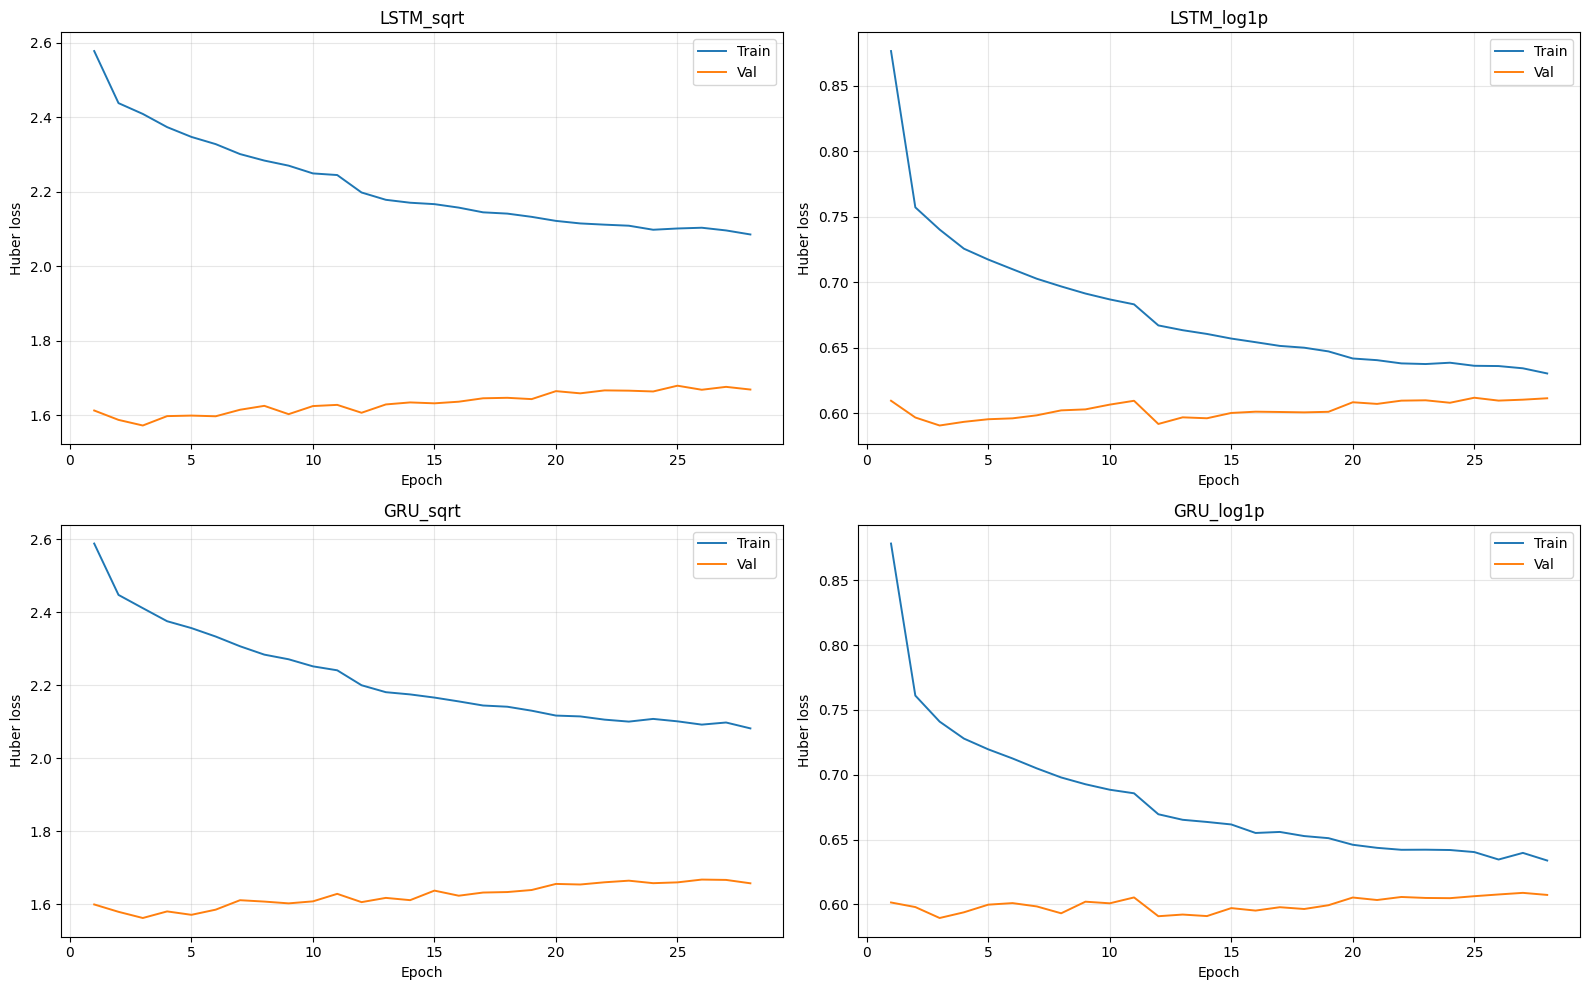

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (key, hist) in zip(axes.flat, histories.items()):
    ep = range(1, len(hist['loss']) + 1)
    ax.plot(ep, hist['loss'], label='Train', linewidth=1.4)
    ax.plot(ep, hist['val_loss'], label='Val', linewidth=1.4)
    ax.set_title(key); ax.set_xlabel('Epoch'); ax.set_ylabel('Huber loss')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/rnn_attn_embed_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 14. Save Results

In [14]:
output = {
    'config': {
        'seq_len': SEQ_LEN, 'batch_size': BATCH_SIZE, 'sw_strength': SW_STRENGTH,
        'n_players': int(n_players), 'player_emb_dim': 8,
        'rnn_units': 128, 'dropout': 0.25, 'rnn_dropout': 0.15,
        'noise': 0.05, 'huber_delta': 1.0, 'lr': 5e-4, 'wd': 5e-4,
    },
    'n_seq_features': n_seq_features,
    'n_static_features': n_static_features,
    'results': results,
}
with open('../results/rnn_attn_embed_results.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)

df_res.to_csv('../results/rnn_attn_embed_comparison.csv', index=False)
print('Saved: results/rnn_attn_embed_results.json')
print('Saved: results/rnn_attn_embed_comparison.csv')


Saved: results/rnn_attn_embed_results.json
Saved: results/rnn_attn_embed_comparison.csv
